In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# EDA
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

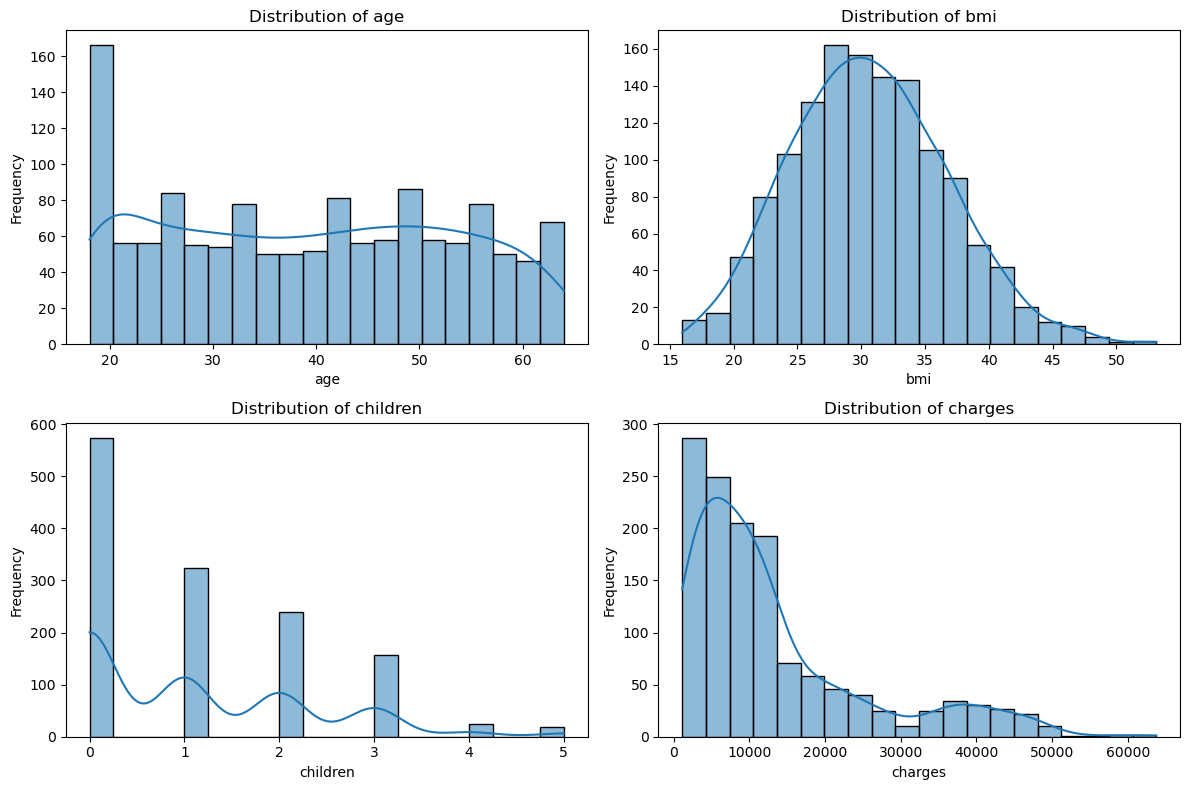

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(12, 8))  # overall figure size

for i, col in enumerate(numeric_columns, 1):  # enumerate from 1
    plt.subplot(2, 2, i)  # 2 rows, 2 columns
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()  # prevent overlap
plt.show()



<Axes: xlabel='children', ylabel='count'>

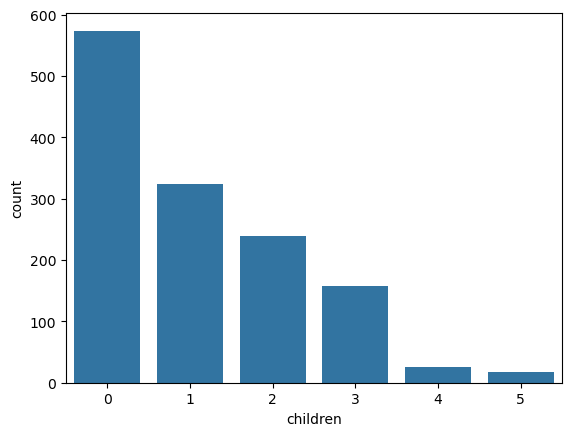

In [10]:
sns.countplot(x=df['children'])

<Axes: xlabel='smoker', ylabel='count'>

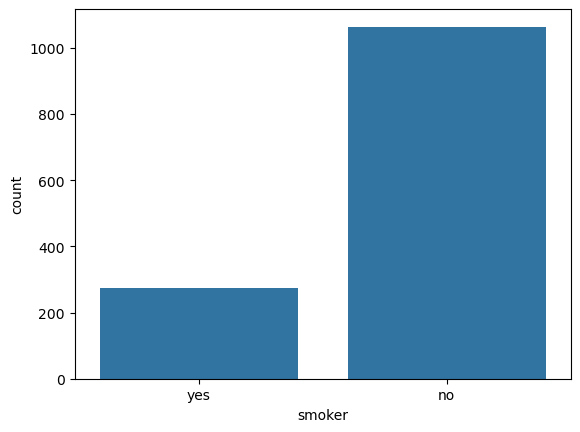

In [9]:
sns.countplot(x=df['smoker'])

In [ ]:
for i, col in enumerate(numeric_columns, 1):  # enumerate from 1
    plt.subplot(2, 2, i)  # 2 rows, 2 columns
    sns.boxplot(x=df[col])
    plt.title(f'variations of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()  # prevent overlap
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
# DATA CLEANING AND PREPRCESSING

In [ ]:
df_clean = df.copy()
print(df_clean.shape)
df_clean.head()

In [ ]:
df_clean.drop_duplicates(inplace=True)
print(df_clean.shape)

In [ ]:
df_clean.isnull().sum()

In [ ]:
df_clean.dtypes

In [ ]:
df_clean['sex'].value_counts()

In [ ]:
df_clean['sex'] = df_clean['sex'].map({"male":0,"female":1})
df_clean.head()

In [ ]:
df_clean['smoker'].value_counts()

In [ ]:
df_clean['smoker'] = df_clean['smoker'].map({"yes":1,"no":0})
df_clean.head()

In [ ]:
df_clean.rename(columns={
    'sex':"is_female",
    'smoker':'is_smoker'
},inplace=True)

In [ ]:
df['region'].value_counts()

In [ ]:
# there is 4 differnet value count in region so we need to make specific columns for it 
df_clean = pd.get_dummies(df_clean,columns=['region'],drop_first=True)

In [ ]:
df_clean.head()

In [ ]:
df_clean =df_clean.astype(int)
df_clean

<!-- Feature Engineering And Extraction -->

In [ ]:
df_clean['bmi_category'] = pd.cut(
    df_clean['bmi'],
    bins=(0, 18.5, 24.9, 29.9, float('inf')),
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
df_clean 

In [ ]:
print(df_clean.columns)

# Then use the correct column name in get_dummies
# For example, if the actual column name is 'BMI_category' (case sensitive)
df_clean = pd.get_dummies(df_clean, columns=["BMI_category"], drop_first=True)

# Or if you need to create the bmi_category column first:
# df_clean['bmi_category'] = # your code to create the column
# df_clean = pd.get_dummies(df_clean, columns=["bmi_category"], drop_first=True)

df_clean

In [ ]:
# print(df_clean.head())
final_df = df_clean[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_southeast', 'bmi_category_Obese']]
final_df